# Quantum Teleportation with Qiskit

## Importing necessary libraries

In [110]:
import math
from pandas import DataFrame as df
import os
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator

In [111]:
from qiskit.visualization import array_to_latex
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

## Initializing a random qubit state

In [184]:
# Create random 1-qubit state
psi = random_statevector(2)


print('psi state: {}'.format(psi))

# Display it in LaTeX
array_to_latex(psi)

psi state: Statevector([ 0.64817217+0.06188758j, -0.39822424-0.64611162j],
            dims=(2,))


<IPython.core.display.Latex object>

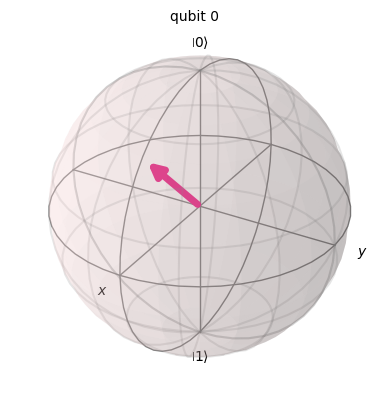

In [185]:
plot_bloch_multivector(psi)

In [186]:
init_state = Initialize(psi)
init_state.label = "initial_state"

## Essential functions for quantum teleportation protocol

In [187]:
def create_bell_pair(qc, a, b):
    """Creates a bell pair in qc using qubits a & b"""
    qc.h(a) # Put qubit a into state |+>
    qc.cx(a,b) # CNOT with a as control and b as target

In [188]:
def alice_gates(qc, psi, a):
    qc.cx(psi, a)
    qc.h(psi)
    qc.barrier()

In [189]:
def measure_and_send(qc, a, b):
    """Measures qubits a & b and 'sends' the results to Bob"""
    qc.barrier()
    qc.measure(a,0)
    qc.measure(b,1)

In [190]:
# This function takes a QuantumCircuit (qc), integer (qubit)
# and ClassicalRegisters (crz & crx) to decide which gates to apply
def bob_gates(qc, qubit, crz, crx):
    # Here we use c_if to control our gates with a classical
    # bit instead of a qubit
    qc.x(qubit).c_if(crx, 1) # Apply gates if the registers 
    qc.z(qubit).c_if(crz, 1) # are in the state '1'

## Executing Quantum Teleportation Protocol

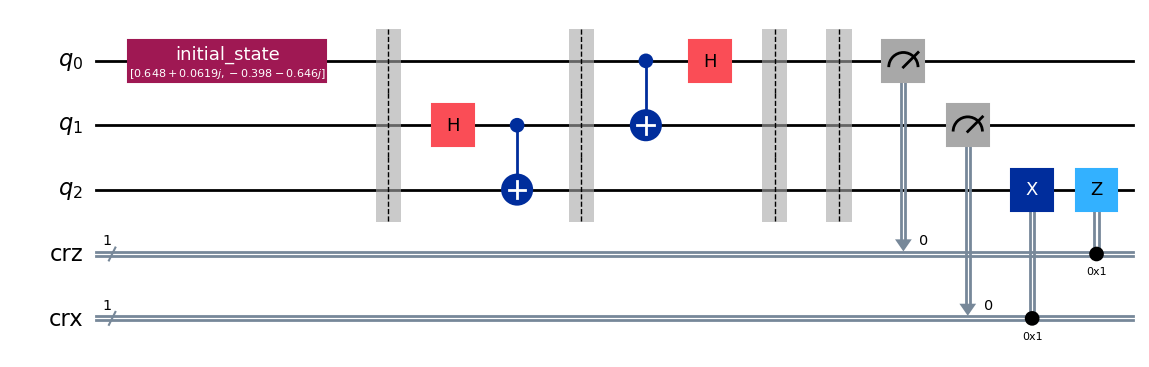

In [191]:
## SETUP
qr = QuantumRegister(3, name="q")   # Protocol uses 3 qubits
crz = ClassicalRegister(1, name="crz") # and 2 classical registers
crx = ClassicalRegister(1, name="crx")
qc = QuantumCircuit(qr, crz, crx)

## STEP 0
# First, let's initialize Alice's q0
qc.append(init_state, [0])
qc.barrier()

## STEP 1
# Now begins the teleportation protocol
create_bell_pair(qc, 1, 2)
qc.barrier()

## STEP 2
# Send q1 to Alice and q2 to Bob
alice_gates(qc, 0, 1)

## STEP 3
# Alice then sends her classical bits to Bob
measure_and_send(qc, 0, 1)

## STEP 4
# Bob decodes qubits
bob_gates(qc, 2, crz, crx)

# Display the circuit
qc.draw('mpl')

## Simulating our Quantum Teleportation Circuit

In [192]:
state = Statevector.from_instruction(qc)   # qc is your circuit
plot_bloch_multivector(state)

QiskitError: 'Cannot convert condition in circuit with multiple classical registers to instruction'

Qubit 0 density matrix:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Qubit 1 density matrix:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Qubit 2 density matrix:
 [[ 0.424+0.j    -0.298+0.394j]
 [-0.298-0.394j  0.576+0.j   ]]


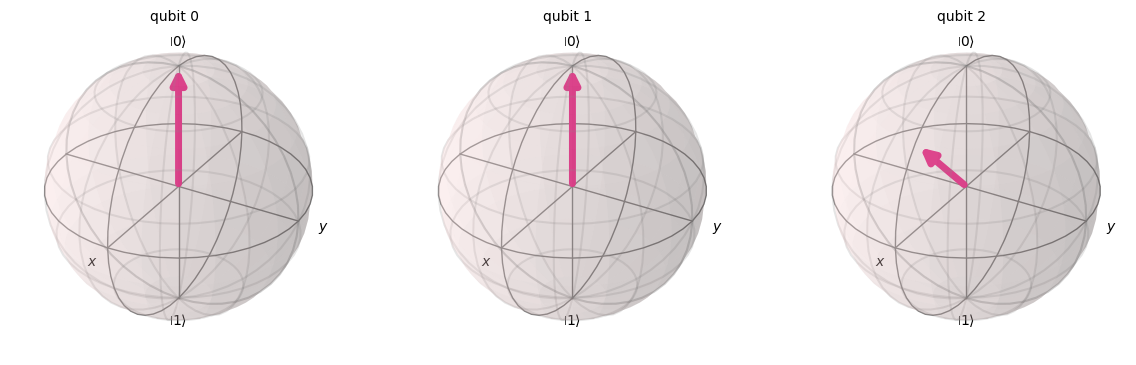

In [199]:
from qiskit.quantum_info import DensityMatrix, partial_trace

sim = AerSimulator(method="density_matrix")

qc_sim = qc.copy()
qc_sim.save_density_matrix()     # IMPORTANT

tqc = transpile(qc_sim, sim) # is your circuit translated into instructions the simulator understands.
res = sim.run(tqc, shots=1).result() # run means simulate this quantum circuit on the backend. A shot=1 complete run of the circuit from start to finish.
"""
res = sim.run(tqc, shots=1) says --> Simulate one full experimental run of my quantum teleportation circuit, including 
Alice’s measurement, classical communication, and Bob’s correction, and give me the final quantum state.
"""
rho = res.data(0)["density_matrix"]   # restives quantum density matrix (3 qubits) from res
dm = DensityMatrix(rho)

dm_q0 = partial_trace(dm, [1, 2])
print("Qubit 0 density matrix:\n", np.round(dm_q0.data, 3))
dm_q1 = partial_trace(dm, [0, 2])
print("Qubit 1 density matrix:\n", np.round(dm_q1.data, 3))
dm_q2 = partial_trace(dm, [0, 1])
print("Qubit 2 density matrix:\n", np.round(dm_q2.data, 3))

plot_bloch_multivector(dm)            # <-- gives 3 Bloch spheres (qubit 0/1/2)

In [200]:
print(dm)

DensityMatrix([[ 0.42395723+0.j        ,  0.        +0.j        ,
                -0.        +0.j        ,  0.        +0.j        ,
                -0.29810415+0.39414643j,  0.        +0.j        ,
                 0.        +0.j        ,  0.        +0.j        ],
               [ 0.        +0.j        ,  0.        +0.j        ,
                -0.        +0.j        ,  0.        +0.j        ,
                -0.        +0.j        ,  0.        +0.j        ,
                 0.        +0.j        ,  0.        +0.j        ],
               [ 0.        -0.j        ,  0.        +0.j        ,
                 0.        +0.j        , -0.        +0.j        ,
                 0.        +0.j        , -0.        +0.j        ,
                 0.        -0.j        ,  0.        +0.j        ],
               [ 0.        +0.j        ,  0.        +0.j        ,
                -0.        +0.j        ,  0.        +0.j        ,
                -0.        +0.j        ,  0.        +0.j        ,
       


Total Counts are: {'0 1': 256, '1 1': 243, '1 0': 265, '0 0': 236}


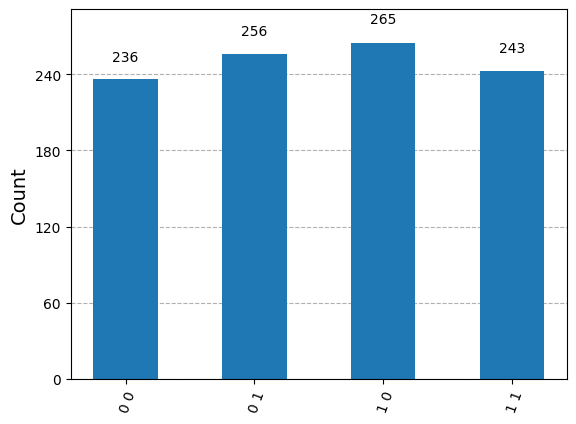

In [79]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

In [201]:
from qiskit.quantum_info import DensityMatrix, state_fidelity
import numpy as np

rho_expected = DensityMatrix(psi)          # |psi><psi|
print(np.round(rho_expected.data, 3))

print("Fidelity:", state_fidelity(dm_q2, rho_expected))


[[ 0.424+0.j    -0.298+0.394j]
 [-0.298-0.394j  0.576+0.j   ]]
Fidelity: 1.0000000000000009
